# DriftMind Drift Adaptation Benchmark 

<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Roman\AppData\Local\Temp\ipykernel_44076\1631342452.py:64: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Model Robustness: $\sigma$ vs. $sMAE$')
C:\Users\Roman\AppData\Local\Temp\ipykernel_44076\1631342452.py:65: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Standard Deviation ($\sigma$) - Log Scale')


,Experiment Id,Category,Dataset,Mean,StdDev,Min,Max,Range,MAE,sMAE,Time,Points,Throughput
0,0,NETWORK IP TRAFFIC,accessnetwork_TCP_TCP_frame_length.csv,843.9509,223.8227,452.8859,1491.3767,1038.4908,5.0635,0.0049,00:00:01,1670,1199.1247
1,1,NETWORK IP TRAFFIC,accessnetwork_TCP_TCP_tcp_window_size.csv,29015.4389,2902.2413,22123.8458,32839.7745,10715.9287,44.8297,0.0042,00:00:00,1670,4303.6649
2,2,NETWORK IP TRAFFIC,afs-kaserver_TCP_TCP_frame_length.csv,783.6823,319.4542,221.1309,1298.2731,1077.1423,4.2289,0.0039,00:00:00,1868,5060.4396
3,3,NETWORK IP TRAFFIC,afs-kaserver_TCP_TCP_tcp_window_size.csv,60022.1327,5380.3203,31099.8011,65486.5222,34386.7210,107.5649,0.0031,00:00:00,1868,4120.8054
4,4,NETWORK IP TRAFFIC,agcat_TCP_TCP_frame_length.csv,556.3203,590.0844,68.0000,1447.3138,1379.3138,2.2824,0.0017,00:00:00,999,9355.7692
5,5,NETWORK IP TRAFFIC,agcat_TCP_TCP_tcp_window_size.csv,43764.9924,13315.2350,32127.2661,64362.7394,32235.4733,50.0135,0.0016,00:00:00,999,11865.8537
6,6,NETWORK IP TRAFFIC,amt-esd-prot_TCP_TCP_frame_length.csv,618.1122,117.5931,328.8377,904.1157,575.2780,4.9333,0.0086,00:00:00,1373,5520.4918
7,7,NETWORK IP TRAFFIC,amt-esd-prot_TCP_TCP_tcp_window_size.csv,27286.4536,7042.6554,11121.6397,32768.0000,21646.3603,43.4694,0.0020,00:00:00,1373,10052.2388
8,8,NETWORK IP TRAFFIC,avast_TCP_TCP_frame_length.csv,1390.3148,211.1173,656.1298,1522.0000,865.8702,2.0636,0.0024,00:00:00,1373,6570.7317
9,9,NETWORK IP TRAFFIC,boinc-client_TCP_TCP_frame_length.csv,627.8577,116.0240,336.0311,988.3726,652.3415,4.0160,0.0062,00:00:00,1729,6238.0952


### Summary Metrics per Category ###


,File_Count,Avg_sMAE,Avg_TPS,Total_Points
Category,,,,
ELECTICITY USAGE,25,0.000744,2726.415200,1114880
NETWORK IP TRAFFIC,229,0.002950,5691.946108,1317516
NETWORK RAN 5G CELL KPI,80,0.003840,7654.135039,73440
SYNTHETIC,2,0.044750,837.560800,40000


C:\Users\Roman\AppData\Local\Temp\ipykernel_44076\1631342452.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Avg_sMAE', data=summary, palette='viridis')


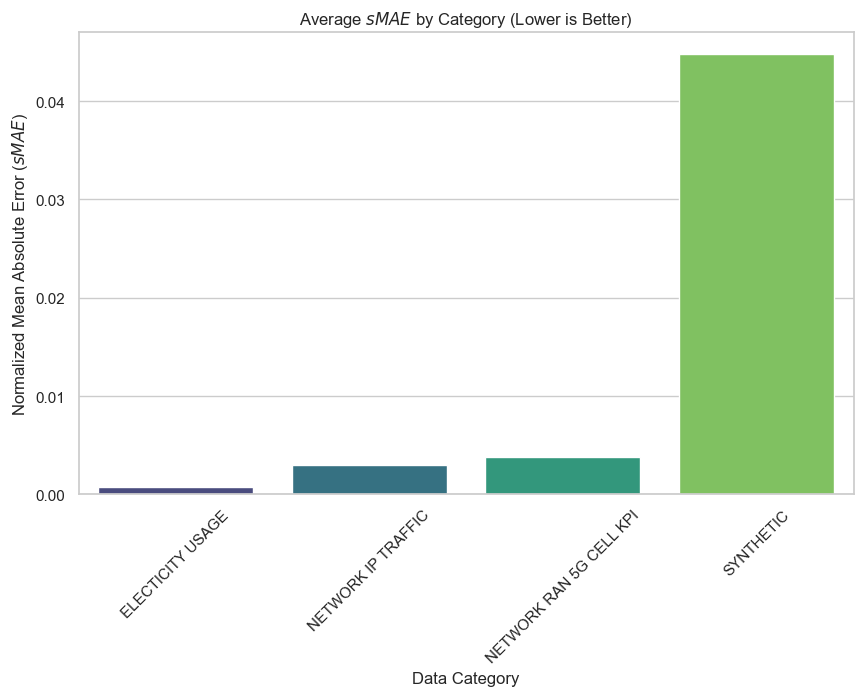

C:\Users\Roman\AppData\Local\Temp\ipykernel_44076\1631342452.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y='Avg_TPS', data=summary, palette='magma')


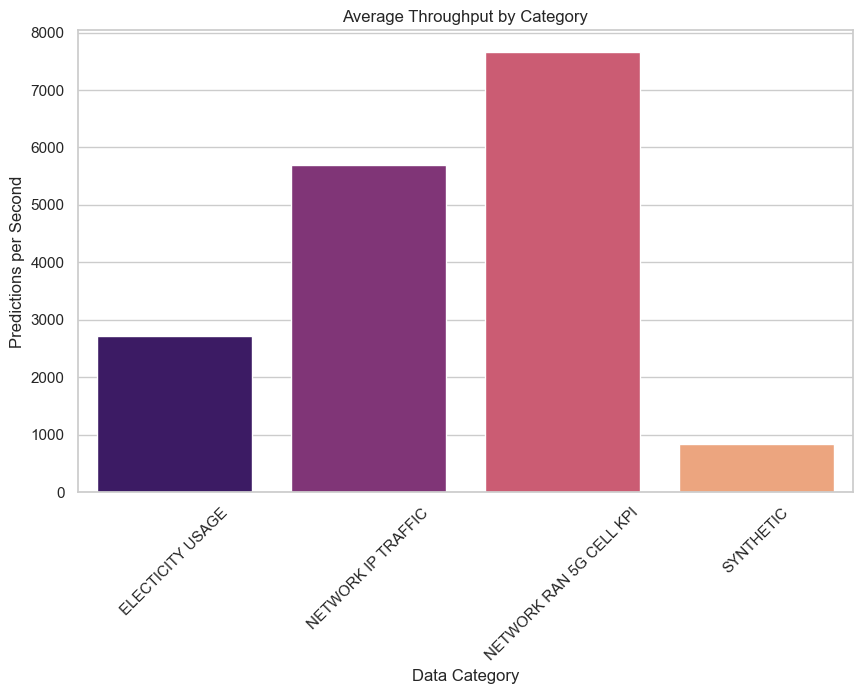

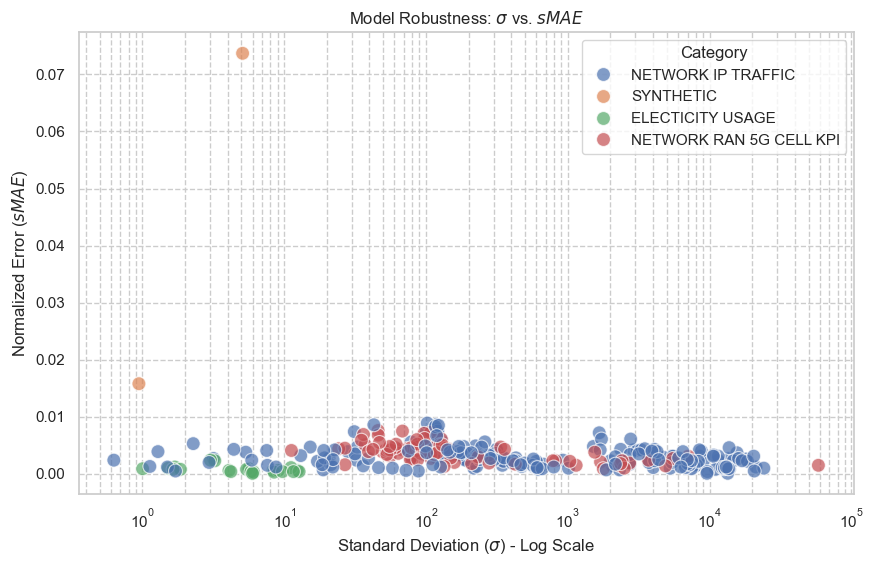

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
from tqdm import tqdm
from RR_ARIMA import TriggeredARIMABaseline


# Load the dataset (headers are now detected automatically)
df = pd.read_csv('data\\driftmind_results\\analysis_results.csv')

# Configure pandas to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Display the table
display(df)

# --- SECTION 1: Metrics per Category ---
summary = df.groupby('Category').agg({
    'Dataset': 'count',
    'sMAE': 'mean',
    'Throughput': 'mean',
    'Points': 'sum'
}).rename(columns={
    'Dataset': 'File_Count', 
    'sMAE': 'Avg_sMAE', 
    'Throughput': 'Avg_TPS', 
    'Points': 'Total_Points'
}).sort_values('Avg_sMAE')

print("### Summary Metrics per Category ###")
display(summary)

# --- SECTION 2: Visualizations ---
sns.set_theme(style="whitegrid")

# Graph 1: Average Error (sMAE) by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=summary.index, y='Avg_sMAE', data=summary, palette='viridis')
plt.title('Average $sMAE$ by Category (Lower is Better)')
plt.ylabel('Normalized Mean Absolute Error ($sMAE$)')
plt.xlabel('Data Category')
plt.xticks(rotation=45)
plt.show()

# Graph 2: Throughput by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=summary.index, y='Avg_TPS', data=summary, palette='magma')
plt.title('Average Throughput by Category')
plt.ylabel('Predictions per Second')
plt.xlabel('Data Category')
plt.xticks(rotation=45)
plt.show()

# Graph 3: Robustness Check (Volatility vs Error)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='StdDev', y='sMAE', hue='Category', data=df, s=100, alpha=0.7)
plt.xscale('log') # Log scale helps visualize wide ranges of variance
plt.title('Model Robustness: $\sigma$ vs. $sMAE$')
plt.xlabel('Standard Deviation ($\sigma$) - Log Scale')
plt.ylabel('Normalized Error ($sMAE$)')
plt.grid(True, which="both", ls="--")
plt.show()

## Ploting

In [2]:
def visualize_experiment_full(experiment_id, 
                         main_csv='data\\driftmind_results\\analysis_results.csv', 
                         base_path=r'data\\driftmind_results\\experiments'):
    """
    Looks up metadata from the main table, prints metrics, 
    and visualizes the experiment results.
    """
    # 1. Load and search Metadata from main CSV
    try:
        df_main = pd.read_csv(main_csv)
    except Exception as e:
        print(f"Error loading {main_csv}: {e}")
        return

    exp_info = df_main[df_main['Experiment Id'] == experiment_id]
    
    if exp_info.empty:
        print(f"Error: Experiment ID {experiment_id} not found in {main_csv}")
        return

    # Print the metadata nicely
    print(f"{'='*60}")
    print(f" METADATA FOR EXPERIMENT {experiment_id}")
    print(f"{'='*60}")
    for col in exp_info.columns:
        print(f"{col:<15}: {exp_info.iloc[0][col]}")
    print(f"{'='*60}\n")

    # 2. Search for the individual result file
    search_pattern = os.path.join(base_path, f"Experiment_{experiment_id}_*.csv")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"Error: No result file found for ID {experiment_id} in {base_path}")
        return

    file_path = files[0]
    file_name = os.path.basename(file_path) # Extract just the filename
    
    # 3. Load the prediction data
    df_results = pd.read_csv(file_path, skipinitialspace=True)
    
    # 4. Create the Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Title is the filename
    ax1.set_title(f"File: {file_name}", fontsize=14, fontweight='bold', pad=20)
    
    # Subplot 1: Actual vs Expected
    ax1.plot(df_results.index, df_results['Actual'], label='Actual', color='#1f77b4', alpha=0.8)
    ax1.plot(df_results.index, df_results['Expected'], label='Expected (DriftMind)', 
             color='#ff7f0e', linestyle='--', linewidth=2)
    
    ax1.set_ylabel('Value')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)

    # Subplot 2: Absolute Error (AE)
    ax2.fill_between(df_results.index, df_results['AE'], color='red', alpha=0.15)
    ax2.plot(df_results.index, df_results['AE'], color='red', linewidth=1, label='Abs Error')
    
    ax2.set_ylabel('AE')
    ax2.set_xlabel('Time Steps')
    ax2.grid(True, alpha=0.3)
    
    # Highlight Warm-up
    warmup_count = df_results['Expected'].isna().sum()
    if warmup_count > 0:
        ax1.axvspan(0, warmup_count, color='gray', alpha=0.1, label='Warm-up')
        ax2.axvspan(0, warmup_count, color='gray', alpha=0.1)

    plt.tight_layout()
    plt.show()


 METADATA FOR EXPERIMENT 34
Experiment Id  : 34
Category       : SYNTHETIC
Dataset        : data_stress_val.csv
Mean           : -0.0314
StdDev         : 5.0971
Min            : -18.3397
Max            : 21.1245
Range          : 39.4642
MAE            : 2.9096
sMAE           : 0.0737
Time           : 00:00:39
Points         : 20000
Throughput     : 508.3478



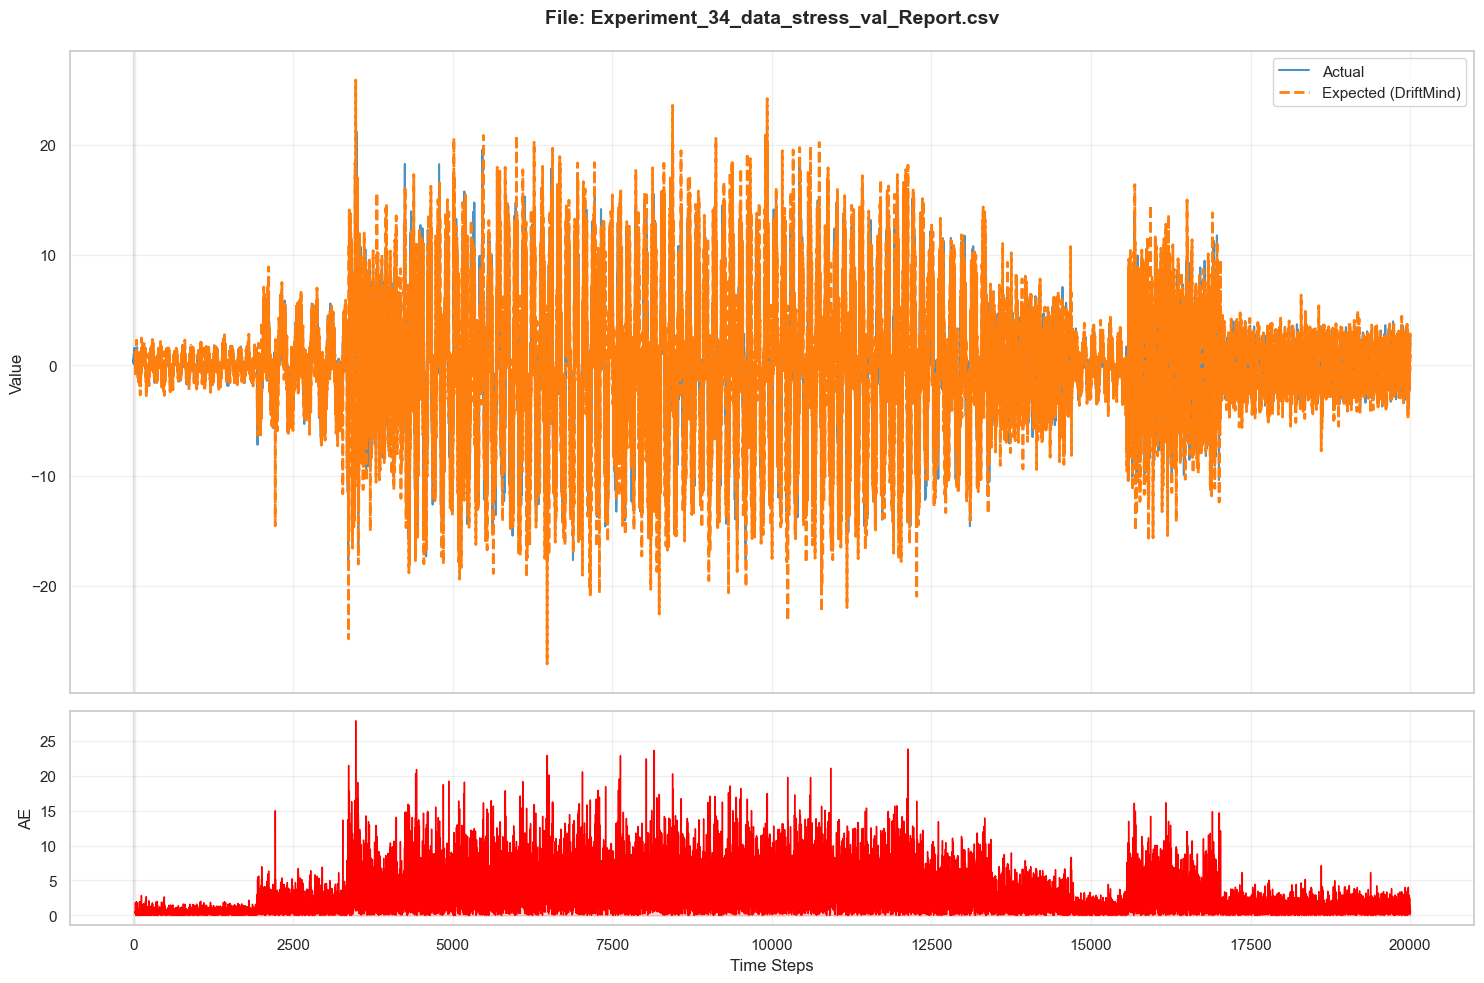

In [15]:
visualize_experiment_full(34)

## Compare with Adaptive Arima

In [3]:
def compare_with_arima(experiment_id, 
                       dm_results_folder=r'data\\driftmind_results\\experiments',
                       main_results_csv='data\\driftmind_results\\analysis_results.csv'):
    """
    Retrieves original signal, runs ARIMA, and generates a two-part 
    comparison: Predictions and Absolute Error residuals.
    """
    # 1. Load Metadata
    df_main = pd.read_csv(main_results_csv)
    if 'Experiment Id' not in df_main.columns:
        cols = ['Experiment Id', 'Category', 'Dataset', 'Mean', 'StdDev', 'Min', 'Max', 
                'Range', 'MAE', 'sMAE', 'Time', 'Points', 'Throughput']
        df_main = pd.read_csv(main_results_csv, names=cols, header=None)

    exp_info = df_main[df_main['Experiment Id'] == experiment_id]
    if exp_info.empty:
        print(f"Error: Experiment ID {experiment_id} not found.")
        return
    
    meta = exp_info.iloc[0]

    # 2. Load DriftMind Results
    search_pattern = os.path.join(dm_results_folder, f"Experiment_{experiment_id}_*.csv")
    match = glob.glob(search_pattern)
    if not match:
        print(f"Error: File for Exp {experiment_id} not found.")
        return
    
    dm_file = match[0]
    df_dm = pd.read_csv(dm_file, skipinitialspace=True)
    
    # 3. Run ARIMA Benchmark
    df_for_arima = pd.DataFrame({'val': df_dm['Actual']})
    print(f"Executing ARIMA benchmark for: {os.path.basename(dm_file)}")
    
    start_time = time.time()
    df_arima = adaptive_online_arima_benchmark(df_for_arima)
    arima_duration = time.time() - start_time
    
    # Calculate Metrics
    arima_ae = np.abs(df_arima['expected'] - df_arima['predicted'])
    arima_mae = np.mean(arima_ae)
    arima_smae = arima_mae / meta['Range']
    arima_tps = len(df_dm) / arima_duration if arima_duration > 0 else 0

    # 4. Print Summary
    print("\n" + "="*60)
    print(f" COMPARISON: DRIFTMIND VS. ADAPTIVE ARIMA")
    print("="*60)
    print(f"{'Metric':<15} | {'DriftMind':<15} | {'ARIMA':<15}")
    print("-" * 50)
    print(f"{'MAE':<15} | {meta['MAE']:<15.4f} | {arima_mae:<15.4f}")
    print(f"{'sMAE':<15} | {meta['sMAE']:<15.4f} | {arima_smae:<15.4f}")
    print(f"{'Throughput':<15} | {meta['Throughput']:<15.2f} | {arima_tps:<15.2f}")
    print("="*60)

    # 5. Visualization (Dual Subplots)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    # --- Top Plot: Predictions ---
    ax1.plot(df_dm.index, df_dm['Actual'], label='Actual (Ground Truth)', color='black', alpha=0.2, linewidth=1)
    ax1.plot(df_dm.index, df_dm['Expected'], label=f"DriftMind Prediction", color='#1f77b4', linewidth=2)
    ax1.plot(df_arima['pos'], df_arima['predicted'], label=f"Adaptive ARIMA", color='#d62728', linestyle='--', alpha=0.8)
    
    ax1.set_title(f"Model Comparison: {os.path.basename(dm_file)}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Value")
    ax1.legend(loc='best', shadow=True)
    ax1.grid(True, alpha=0.2)

    # --- Bottom Plot: Absolute Error (AE) Comparison ---
    # Plotting DriftMind AE
    ax2.plot(df_dm.index, df_dm['AE'], label='DriftMind AE', color='#1f77b4', alpha=0.7)
    ax2.fill_between(df_dm.index, df_dm['AE'], color='#1f77b4', alpha=0.1)
    
    # Plotting ARIMA AE
    ax2.plot(df_arima['pos'], arima_ae, label='ARIMA AE', color='#d62728', alpha=0.7)
    ax2.fill_between(df_arima['pos'], arima_ae, color='#d62728', alpha=0.1)
    
    ax2.set_title("Absolute Error (AE) Comparison", fontsize=12)
    ax2.set_ylabel("Error Amplitude")
    ax2.set_xlabel("Time Step")
    ax2.legend(loc='best', shadow=True)
    ax2.grid(True, alpha=0.2)
    
    # Winner Label
    winner = "DriftMind" if meta['MAE'] < arima_mae else "ARIMA"
    ax1.text(0.01, 0.95, f"WINNER: {winner}", transform=ax1.transAxes, 
             fontsize=12, fontweight='bold', color='green' if winner == "DriftMind" else 'red',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

    plt.tight_layout()
    plt.show()

def adaptive_online_arima_benchmark(
    df,
    training_fraction=0.01,
    arima_order=(5, 1, 0),
    arima_fit_window=200,
    mase_limit=3.0,
    mase_window=10,
    mase_consecutive_steps=20,
    corr_floor=0.20,
    eval_window=100
):
    y = df["val"].to_numpy()
    n = len(y)
    split_idx = int(n * training_fraction)

    # Initial Training
    train_data = y[:split_idx]
    history = list(train_data)
    
    # --- Initialize Adaptive Metrics ---
    # 1. Scaling factor for MASE (Volatility)
    naive_scaling_factor = np.nanmean(np.abs(np.diff(train_data))) or 1e-8
    # 2. Baseline Signal Std for Structural Ratio
    current_signal_std = np.std(train_data) or 1e-8

    model = TriggeredARIMABaseline(order=arima_order)
    model.train(train_data[-arima_fit_window:])

    results = []
    recent_abs_errors = []
    recent_preds = []
    recent_actuals = []
    
    mase_bad_run = 0

    total_retrains = 0

    total_mae=0
    inference_count =0

    print("Executing Adaptive Online ARIMA...")
    test_data = y[split_idx:]
    
    for i, actual_val in enumerate(tqdm(test_data)):
        global_pos = split_idx + i
        window = history[-arima_fit_window:]

        # 1. Predict with current frozen parameters
        pred, latency = model.predict_point(window)
        
        # 2. Compute immediate error
        ae = abs(actual_val - pred) if np.isfinite(pred) else 1e6
        recent_abs_errors.append(ae)
        recent_preds.append(pred)
        recent_actuals.append(actual_val)

        # Keep evaluation windows lean
        if len(recent_abs_errors) > eval_window:
            recent_abs_errors.pop(0)
            recent_preds.pop(0)
            recent_actuals.pop(0)

        # 3. Calculate Adaptive Metrics
        current_mae = np.mean(recent_abs_errors[-mase_window:])
        mase = current_mae / naive_scaling_factor
        
        # Correlation check
        corr = 1.0
        if len(recent_preds) >= eval_window:
            corr = np.corrcoef(recent_preds, recent_actuals)[0, 1]

        # 4. TRIGGER LOGIC
        trigger_fired = False
        reason = ""

        if mase > mase_limit:
            mase_bad_run += 1
            if mase_bad_run >= mase_consecutive_steps:
                trigger_fired = True
                reason = "MASE_DRIFT"
        elif corr < corr_floor:
            trigger_fired = True
            reason = "STRUCTURAL_DRIFT"
        else:
            mase_bad_run = 0

        # 5. ADAPTIVE RESET
        if trigger_fired:
            # Refresh all baselines to current regime
            new_train_window = history[-arima_fit_window:]
            
            # Update Scaling (Naive Error)
            naive_scaling_factor = np.nanmean(np.abs(np.diff(new_train_window))) or 1e-8
            
            # Update Std Baseline
            current_signal_std = np.std(new_train_window) or 1e-8
            
            # Retrain Model
            model.train(new_train_window)
            mase_bad_run = 0
            
            # (Optional) Log event
            #print(f"\n[Retrain] {reason} at {global_pos}. New Scale: {naive_scaling_factor:.4f}")
            total_retrains+=1
        total_mae = total_mae + abs(actual_val-pred)
        inference_count += 1
        results.append({
            "pos": global_pos,
            "expected": actual_val,
            "predicted": pred,
            "mase": mase,
            "corr": corr,
            "latency": latency,
            "retrain": 1 if trigger_fired else 0
        })
        
        history.append(actual_val)
    print(f"Retrains: {total_retrains}")
    total_mae= total_mae/inference_count
    print(f"avg MAe: {total_mae}")
    return pd.DataFrame(results)

    print("hola")

Executing ARIMA benchmark for: Experiment_34_data_stress_val_Report.csv
Executing Adaptive Online ARIMA...


100%|██████████| 19800/19800 [02:04<00:00, 159.10it/s]


Retrains: 106
avg MAe: 2.0258479920848536

 COMPARISON: DRIFTMIND VS. ADAPTIVE ARIMA
Metric          | DriftMind       | ARIMA          
--------------------------------------------------
MAE             | 2.9096          | 2.0258         
sMAE            | 0.0737          | 0.0513         
Throughput      | 508.35          | 160.48         


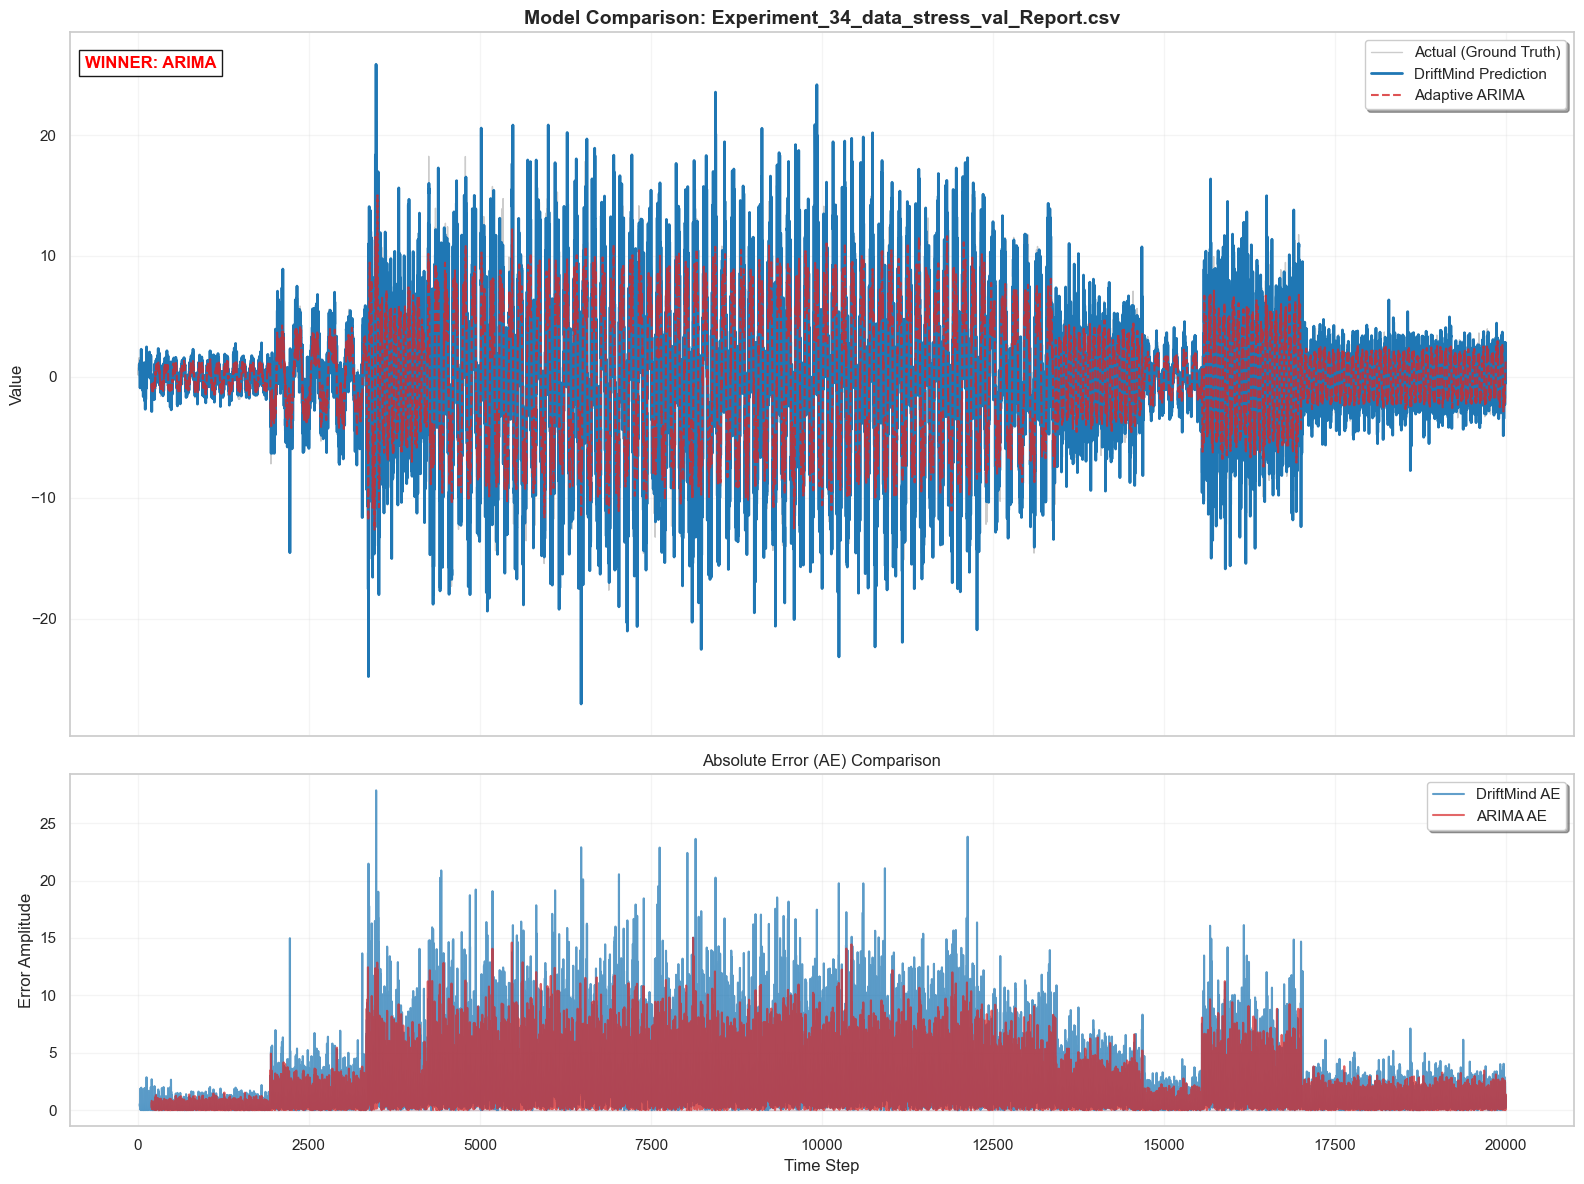

In [4]:
compare_with_arima(34)